<a href="https://colab.research.google.com/github/ADITI9981/Deep_Learning/blob/main/Bank_customer_churn_prediction_using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install jovian opendatasets  --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 2.7 MB/s eta 0:00:00


In [3]:
import opendatasets as od

In [4]:
dataset_url = 'https://www.kaggle.com/datasets/barelydedicated/bank-customer-churn-modeling'

In [5]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aditiyadav9981","key":"0c315aefee6e3c6d92b383cdf916a9fe"}'}

In [7]:
od.download(dataset_url,force=True)

Dataset URL: https://www.kaggle.com/datasets/barelydedicated/bank-customer-churn-modeling


100%|██████████| 262k/262k [00:00<00:00, 184MB/s]

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [35]:
df=pd.read_csv('bank-customer-churn-modeling/Churn_Modelling.csv')

In [36]:
print(type(df))


<class 'pandas.core.frame.DataFrame'>


In [37]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1114,1115,15626147,Maclean,608,France,Female,62,8,144976.50,1,0,0,175836.03,1
8745,8746,15793424,Tan,663,Spain,Female,28,8,61274.70,2,1,0,136054.45,0
2318,2319,15648005,Russell,672,Spain,Male,33,2,0.00,2,1,1,182738.00,0
3144,3145,15638003,Komarova,648,Spain,Male,55,1,81370.07,1,0,1,181534.04,0
4638,4639,15659399,Mazzi,516,Germany,Male,50,7,139675.07,2,1,0,45591.23,0


In [38]:
print(type(df))


<class 'pandas.core.frame.DataFrame'>


In [39]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis='columns', inplace=True, errors='ignore')


In [40]:
df.dtypes

,0
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64


In [51]:

df.shape

(10000, 11)

<ipython-input-53-9671104513a1>:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


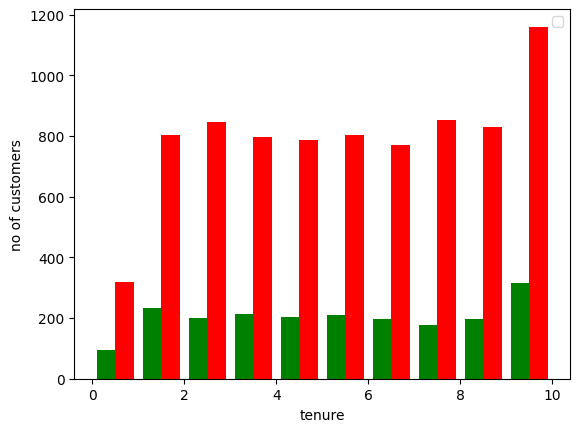

In [53]:
Tenure_Exited_no=df[df.Exited==0].Tenure
Tenure_Exited_yes=df[df.Exited==1].Tenure

plt.xlabel("tenure")
plt.ylabel("no of customers")
plt.hist([Tenure_Exited_yes,Tenure_Exited_no],color=['green','red'])
plt.legend()

<ipython-input-54-06a6f6dfdfac>:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


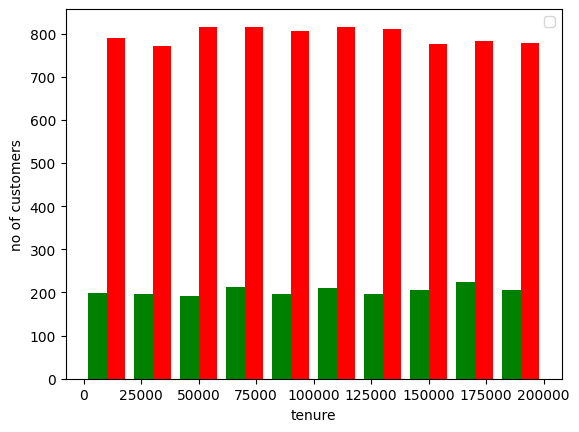

In [54]:
salary_Exited_no=df[df.Exited==0].EstimatedSalary
salary_Exited_yes=df[df.Exited==1].EstimatedSalary

plt.xlabel("tenure")
plt.ylabel("no of customers")
plt.hist([salary_Exited_yes,salary_Exited_no],color=['green','red'])
plt.legend()

In [55]:
def print_unique_col_values(df):
  for column in df:
    if df[column].dtypes=='object':
      print(f'{column}:{df[column].unique()}')

In [56]:
print_unique_col_values(df)

Geography:['France' 'Spain' 'Germany']
Gender:['Female' 'Male']


In [58]:
df['Gender'].replace({'Female':1,'Male':0},inplace=True)

<ipython-input-58-e608bb382eef>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace({'Female':1,'Male':0},inplace=True)
<ipython-input-58-e608bb382eef>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'].replace({'Female':1,'Male':0},inplace=True)


In [59]:
print_unique_col_values(df)

Geography:['France' 'Spain' 'Germany']


In [60]:
df2=pd.get_dummies(data=df,columns=['Geography'])
df2.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
       'Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype='object')

In [62]:
df2.sample(5)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
3695,571,0,40,10,112896.86,1,1,1,121402.53,0,True,False,False
1437,670,1,31,9,0.00,1,0,1,76254.83,0,True,False,False
4796,719,0,35,1,100829.94,1,1,1,165008.97,0,False,False,True
3136,607,0,44,0,0.00,2,1,1,81140.09,0,True,False,False
9605,736,1,29,9,0.00,2,0,0,176152.70,0,True,False,False


In [63]:
cols_to_scale=['Tenure','EstimatedSalary','Balance','Age','CreditScore','NumOfProducts']

from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df2[cols_to_scale]=scaler.fit_transform(df2[cols_to_scale])

In [64]:
df2.sample(5)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
375,0.838,1,0.283784,0.8,0.000000,0.000000,0,1,0.105032,0,True,False,False
5200,0.324,0,0.324324,0.9,0.374478,0.333333,1,0,0.074092,0,False,True,False
7597,0.772,0,0.148649,0.4,0.000000,0.333333,0,0,0.258492,0,True,False,False
6440,0.880,1,0.391892,1.0,0.592417,0.000000,0,1,0.080550,1,True,False,False
4664,0.694,1,0.067568,1.0,0.000000,0.333333,1,1,0.398651,0,True,False,False


In [65]:
x=df2.drop('Exited',axis='columns')
y=df2['Exited']

In [66]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=5)

In [67]:
x_train.shape

(8000, 12)

In [68]:
x_test.shape

(2000, 12)

In [70]:
import tensorflow as tf
from tensorflow import keras

model=keras.Sequential([
    keras.layers.Dense(26,input_shape=(12,),activation='relu'),
    keras.layers.Dense(1,activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.fit(x_train,y_train,epochs=100)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7955 - loss: 0.5276
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8024 - loss: 0.4680
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8029 - loss: 0.4603
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8077 - loss: 0.4455
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8129 - loss: 0.4414
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8022 - loss: 0.4486
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8240 - loss: 0.4151
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8086 - loss: 0.4422
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8216 - loss: 0.4205
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8217 - loss: 0.4173
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8186 - loss: 0.4206
Epoch 12/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [71]:
model.evaluate(x_test,y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8475 - loss: 0.3578


[0.3553284704685211, 0.8514999747276306]

In [72]:
yp=model.predict(x_test)
yp[:5]

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


array([[0.03780773],
       [0.07782789],
       [0.07139531],
       [0.10241006],
       [0.07110316]], dtype=float32)

In [73]:
y_test[:5]

,Exited
7054,0
442,0
3954,0
2288,0
3196,0


In [74]:
y_pred=[]
for element in yp:
  if element>0.5:
    y_pred.append(1)
  else:
    y_pred.append(0)

In [75]:
y_pred[:5]

[0, 0, 0, 0, 0]

In [76]:
from sklearn.metrics import confusion_matrix,classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1595
           1       0.73      0.42      0.53       405

    accuracy                           0.85      2000
   macro avg       0.80      0.69      0.72      2000
weighted avg       0.84      0.85      0.84      2000



Text(95.72222222222221, 0.5, 'Truth')

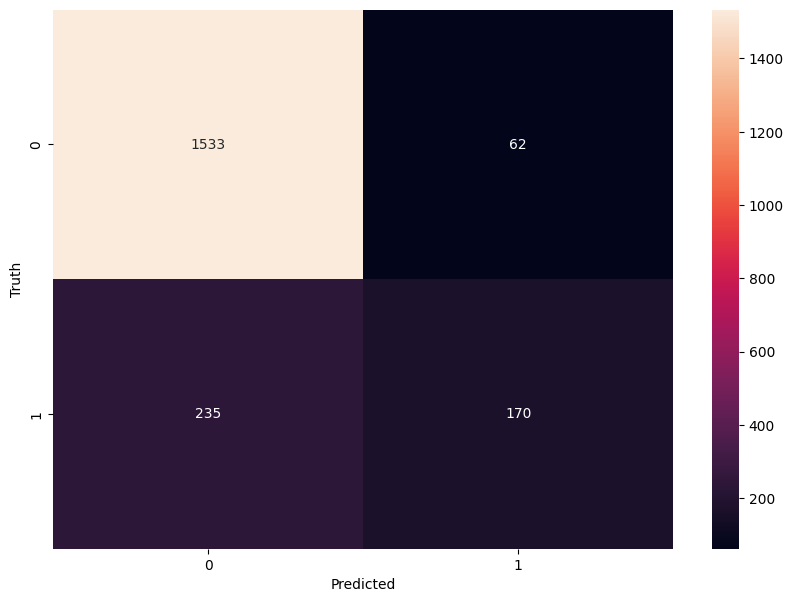

In [77]:
cm=tf.math.confusion_matrix(labels=y_test,predictions=y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')